In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import cobra
from cobra.io import read_sbml_model
from cobra import Model as CobraModel
import ast
import random
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize, LabelEncoder, MinMaxScaler
import matplotlib.colors as mcolors

In [2]:
model = read_sbml_model('yeast-GEM.xml')

In [3]:
#import simoff trajectorie s from another notebook. these are dictionaries of dictionaries of reaction ids (keys) and fluxes (values)
%store -r all_fluxes_slow
%store -r all_fluxes_fast

### Generate random dataframe of solutions for slower growing condition

In [6]:
#generate df of random fluxes for pca
#include four reactions that were in the final simoff search
biomass = model.reactions.get_by_id('r_2111')
glycerol = model.reactions.get_by_id('r_1808')
ethanol = model.reactions.get_by_id('r_1761')
ammonium = model.reactions.get_by_id('r_1654')

reaction_ids = [r.id for r in model.reactions]

# Dictionary to store all flux vectors
columns_dict = {}

labels = ['biomass', 'glycerol', 'ethanol', 'ammonium']

with model:
    for i in range(1000):
        print(i, '/1000')
    
        # Random coefficients normalized by L1 norm
        coefficients = [random.uniform(-1, 1) for _ in range(4)]
        abs_sum = sum(abs(c) for c in coefficients)
        coefficients = [c / abs_sum for c in coefficients]
    
        # Build objective
        model.objective = {
            biomass: coefficients[0],
            glycerol: coefficients[1],
            ethanol:coefficients[2],
            ammonium:coefficients[3]
        }
    
        # Column name
        header = "{" + ", ".join(
            f"{name}:{coeff:.4f}" for name, coeff in zip(labels, coefficients)
        ) + "}"
    
        # Run optimization safely
        solution = model.optimize()
        fluxes = solution.fluxes.to_list()
        # Store flux vector
        columns_dict[header] = fluxes

# Build DataFrame all at once
random_df_slow = pd.DataFrame(columns_dict, index=reaction_ids)
random_df_slow.index.name = "reaction_ids"

0 /1000
1 /1000
2 /1000
3 /1000
4 /1000
5 /1000
6 /1000
7 /1000
8 /1000
9 /1000
10 /1000
11 /1000
12 /1000
13 /1000
14 /1000
15 /1000
16 /1000
17 /1000
18 /1000
19 /1000
20 /1000
21 /1000
22 /1000
23 /1000
24 /1000
25 /1000
26 /1000
27 /1000
28 /1000
29 /1000
30 /1000
31 /1000
32 /1000
33 /1000
34 /1000
35 /1000
36 /1000
37 /1000
38 /1000
39 /1000
40 /1000
41 /1000
42 /1000
43 /1000
44 /1000
45 /1000
46 /1000
47 /1000
48 /1000
49 /1000
50 /1000
51 /1000
52 /1000
53 /1000
54 /1000
55 /1000
56 /1000
57 /1000
58 /1000
59 /1000
60 /1000
61 /1000
62 /1000
63 /1000
64 /1000
65 /1000
66 /1000
67 /1000
68 /1000
69 /1000
70 /1000
71 /1000
72 /1000
73 /1000
74 /1000
75 /1000
76 /1000
77 /1000
78 /1000
79 /1000
80 /1000
81 /1000
82 /1000
83 /1000
84 /1000
85 /1000
86 /1000
87 /1000
88 /1000
89 /1000
90 /1000
91 /1000
92 /1000
93 /1000
94 /1000
95 /1000
96 /1000
97 /1000
98 /1000
99 /1000
100 /1000
101 /1000
102 /1000
103 /1000
104 /1000
105 /1000
106 /1000
107 /1000
108 /1000
109 /1000
110 /1000


C:\Users\p04121km\AppData\Local\Temp\ipykernel_11788\4232019886.py:30: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


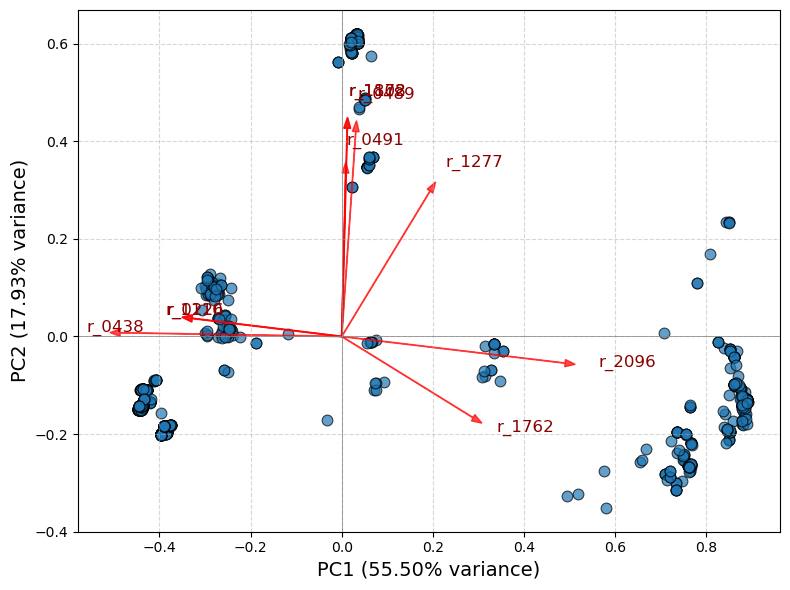

In [7]:
#visualise just the random distribution
# --- Step 1: Normalize the data ---
X = normalize(random_df_slow.T)  # shape: samples × features

# --- Step 2: PCA for 2D visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Put PCA results in a DataFrame
df_pca = pd.DataFrame(X_pca, index=random_df_slow.columns, columns=['PC1', 'PC2'])

# --- Step 4: Compute PCA loadings ---
loadings = pd.DataFrame(
    pca.components_.T,  # features × PCs
    index=random_df_slow.index,
    columns=['PC1', 'PC2']
)

# Get top 5 features for either PC
top_features = set(
    loadings['PC1'].abs().sort_values(ascending=False).head(5).index
).union(
    loadings['PC2'].abs().sort_values(ascending=False).head(5).index
)

# --- Step 5: Plot PCA with clusters and top loadings ---
plt.figure(figsize=(8, 6))

# Scatter plot
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    palette='Set1',
    s=60,
    alpha=0.7,
    legend=False,
    edgecolor='black',   # <-- add this
    linewidth=0.8 # remove legend
)

# Plot top feature loadings as arrows
scale = 1.5  # adjust arrow length
for feature in top_features:
    x_loading = loadings.loc[feature, 'PC1'] * scale
    y_loading = loadings.loc[feature, 'PC2'] * scale
    plt.arrow(0, 0, x_loading, y_loading, color='red', alpha=0.7,
              head_width=0.015, length_includes_head=True)
    plt.text(x_loading * 1.1, y_loading * 1.1, feature, color='darkred', fontsize=12)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)",fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)",fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
#plt.savefig('PCA_random_df_slow_281125.png',bbox_inches='tight',dpi=300)
plt.show()

In [10]:
#import simoff trajectory for slower growing yeast condition with no dropout
%store -r slow_combinations_no_dropout
slow_accuracies = slow_combinations_no_dropout[2]['accuracy'].to_dict()

### Figure 5e

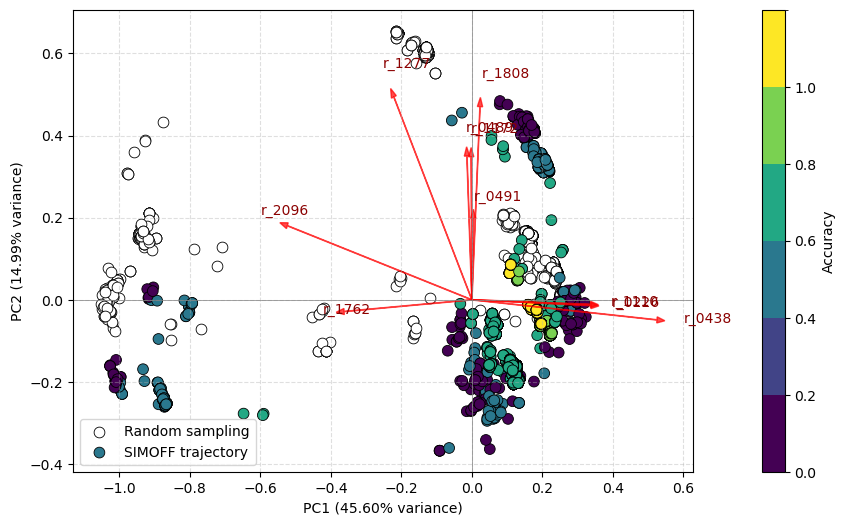

In [17]:
#combine simoff trajectory df and random solutions df
slow_trajectory_df = pd.DataFrame.from_dict(all_fluxes_slow, orient="columns")
joint_df_slow = pd.concat([slow_trajectory_df, random_df_slow], axis=1)

dataset_labels = (
    ["SIMOFF trajectory"] * slow_trajectory_df.shape[1]
    + ["Random sampling"] * random_df_slow.shape[1]
)

#pca
X = normalize(joint_df_slow.T)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(
    X_pca,
    index=joint_df_slow.columns,
    columns=["PC1", "PC2"]
)
df_pca["dataset"] = dataset_labels

# Add accuracy for trajectory only for colormapping
df_pca["accuracy"] = np.nan
df_pca.loc[slow_trajectory_df.columns, "accuracy"] = np.array(
    list(slow_accuracies.values()), dtype=float
)

# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=joint_df_slow.index,
    columns=["PC1", "PC2"]
)

# Split datasets
df_random = df_pca[df_pca["dataset"] == "Random sampling"]
df_traj   = df_pca[df_pca["dataset"] == "SIMOFF trajectory"]

#create colour map for accuracies
accuracy_levels = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
boundaries = accuracy_levels + [1.01]

base_cmap = plt.cm.viridis
colors = base_cmap(np.linspace(0, 1, len(accuracy_levels)))
cmap_discrete = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap_discrete.N)

#plot
plt.figure(figsize=(10, 6))

# Random points
plt.scatter(
    df_random["PC1"],
    df_random["PC2"],
    s=60,
    c="white",
    edgecolor="black",
    linewidth=0.6,
    label="Random sampling"
)

# Trajectory points
sc = plt.scatter(
    df_traj["PC1"],
    df_traj["PC2"],
    s=60,
    c=df_traj["accuracy"],
    cmap=cmap_discrete,
    norm=norm,
    edgecolor="black",
    linewidth=0.6,
    label="SIMOFF trajectory"
)

# Colorbar
cbar = plt.colorbar(sc, ticks=accuracy_levels, label="Accuracy")
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0 + 0.03, pos.y0, pos.width, pos.height])

# Loadings arrows
scale = 1.5
for feature in top_features:
    x = loadings.loc[feature, "PC1"] * scale
    y = loadings.loc[feature, "PC2"] * scale
    plt.arrow(
        0, 0, x, y,
        color="red",
        alpha=0.7,
        head_width=0.015,
        length_includes_head=True
    )
    plt.text(x * 1.1, y * 1.1, feature, color="darkred", fontsize=10)

# Axes & styling
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.legend(loc="lower left")

plt.show()

### Generate random dataframe of solutions for faster growing condition

In [4]:
#include two reactions that were in the final simoff search
biomass = model.reactions.get_by_id('r_2111')
glycerol = model.reactions.get_by_id('r_1808')

reaction_ids = [r.id for r in model.reactions]

# Storage
columns_dict = {}

N = 1000  # number of samples

for i in range(N):
    print(i, "/", N)

    # Random coefficients for the two reactions
    coeffs = [random.uniform(-1, 1) for _ in range(2)]
    abs_sum = sum(abs(c) for c in coeffs)
    coeffs = [c / abs_sum for c in coeffs]  # normalize to L1 = 1

    header = f"sample_{i}_biomass{coeffs[0]:.4f}_glycerol{coeffs[1]:.4f}"

    # Use context manager to safely modify objective
    with model:
        model.objective = {
            biomass: coeffs[0],
            glycerol: coeffs[1]
        }

        # Add a solver timeout (works for GLPK, Gurobi, etc.)
        try:
            model.solver.configuration.timeout = 1  # seconds
        except:
            model.solver.configuration.timeout = int(1 * 1000)  # ms for some solvers

        # Optimize safely
        try:
            sol = model.optimize()
        except:
            print("⚠ Solver crashed, skipping run.")
            continue

        if sol.status != "optimal":
            print("⚠ Non-optimal solution, skipping run.")
            continue

        fluxes = sol.fluxes.reindex(reaction_ids).to_list()
        columns_dict[header] = fluxes

# Build DataFrame all at once
random_df_fast = pd.DataFrame(columns_dict, index=reaction_ids)
random_df_fast.index.name = "reaction_ids"

0 / 1000
1 / 1000
2 / 1000
3 / 1000
4 / 1000
5 / 1000
6 / 1000
7 / 1000
8 / 1000
9 / 1000
10 / 1000
11 / 1000
12 / 1000
13 / 1000
14 / 1000
15 / 1000
16 / 1000
17 / 1000
18 / 1000
19 / 1000
20 / 1000
21 / 1000
22 / 1000
23 / 1000
24 / 1000
25 / 1000
26 / 1000
27 / 1000
28 / 1000
29 / 1000
30 / 1000
31 / 1000
32 / 1000
33 / 1000
34 / 1000
35 / 1000
36 / 1000
37 / 1000
38 / 1000
39 / 1000
40 / 1000
41 / 1000
42 / 1000
43 / 1000
44 / 1000
45 / 1000
46 / 1000
47 / 1000
48 / 1000
49 / 1000
50 / 1000
51 / 1000
52 / 1000
53 / 1000
54 / 1000
55 / 1000
56 / 1000
57 / 1000
58 / 1000
59 / 1000
60 / 1000
61 / 1000
62 / 1000
63 / 1000
64 / 1000
65 / 1000
66 / 1000
67 / 1000
68 / 1000
69 / 1000
70 / 1000
71 / 1000
72 / 1000
73 / 1000
74 / 1000
75 / 1000
76 / 1000
77 / 1000
78 / 1000
79 / 1000
80 / 1000
81 / 1000
82 / 1000
83 / 1000
84 / 1000
85 / 1000
86 / 1000
87 / 1000
88 / 1000
89 / 1000
90 / 1000
91 / 1000
92 / 1000
93 / 1000
94 / 1000
95 / 1000
96 / 1000
97 / 1000
98 / 1000
99 / 1000
100 / 1000

C:\Users\p04121km\AppData\Local\Temp\ipykernel_11416\3908469123.py:30: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


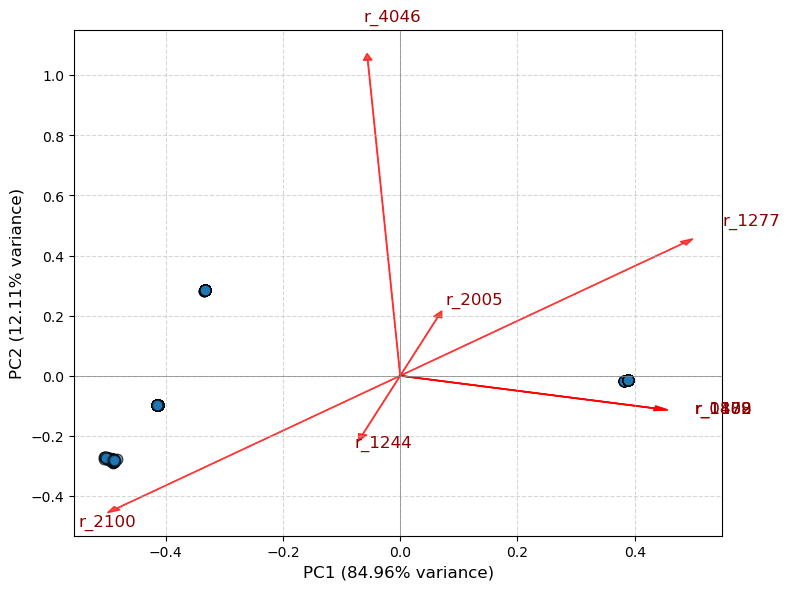

In [6]:
#visualise just the random distribution
# --- Step 1: Normalize the data ---
X = normalize(random_df_fast.T)  # shape: samples × features

# --- Step 2: PCA for 2D visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Put PCA results in a DataFrame
df_pca = pd.DataFrame(X_pca, index=random_df_fast.columns, columns=['PC1', 'PC2'])

# --- Step 4: Compute PCA loadings ---
loadings = pd.DataFrame(
    pca.components_.T,  # features × PCs
    index=random_df_fast.index,
    columns=['PC1', 'PC2']
)

# Get top 5 features for either PC
top_features = set(
    loadings['PC1'].abs().sort_values(ascending=False).head(5).index
).union(
    loadings['PC2'].abs().sort_values(ascending=False).head(5).index
)

# --- Step 5: Plot PCA with clusters and top loadings ---
plt.figure(figsize=(8, 6))

# Scatter plot
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    palette='Set1',
    s=60,
    alpha=0.7,
    legend=False,
    edgecolor='black',   # <-- add this
    linewidth=0.8 # remove legend
)

# Plot top feature loadings as arrows
scale = 1.5  # adjust arrow length
for feature in top_features:
    x_loading = loadings.loc[feature, 'PC1'] * scale
    y_loading = loadings.loc[feature, 'PC2'] * scale
    plt.arrow(0, 0, x_loading, y_loading, color='red', alpha=0.7,
              head_width=0.015, length_includes_head=True)
    plt.text(x_loading * 1.1, y_loading * 1.1, feature, color='darkred', fontsize=12)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)",fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)",fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
#plt.savefig('PCA_random_df_fast_281125.png',bbox_inches='tight',dpi=300)
plt.show()

In [7]:
#import simoff trajectory for slower growing yeast condition with no dropout
%store -r fast_combinations_no_dropout
fast_accuracies = fast_combinations_no_dropout[2]['accuracy'].to_dict()

### Figure 5f

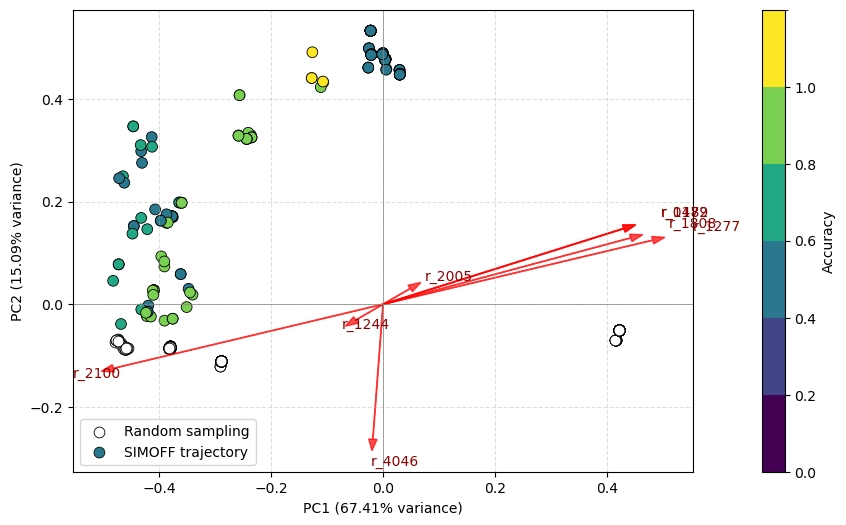

In [8]:
#combine simoff trajectory df and random solutions df
fast_trajectory_df = pd.DataFrame.from_dict(all_fluxes_fast, orient="columns")
joint_df_fast = pd.concat([fast_trajectory_df, random_df_fast], axis=1)

dataset_labels = (
    ["SIMOFF trajectory"] * fast_trajectory_df.shape[1]
    + ["Random sampling"] * random_df_fast.shape[1]
)

#pca
X = normalize(joint_df_fast.T)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(
    X_pca,
    index=joint_df_fast.columns,
    columns=["PC1", "PC2"]
)
df_pca["dataset"] = dataset_labels

# Add accuracy for trajectory only for colormapping
df_pca["accuracy"] = np.nan
df_pca.loc[fast_trajectory_df.columns, "accuracy"] = np.array(
    list(fast_accuracies.values()), dtype=float
)

# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=joint_df_fast.index,
    columns=["PC1", "PC2"]
)

# Split datasets
df_random = df_pca[df_pca["dataset"] == "Random sampling"]
df_traj   = df_pca[df_pca["dataset"] == "SIMOFF trajectory"]

#create colour map for accuracies
accuracy_levels = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
boundaries = accuracy_levels + [1.01]

base_cmap = plt.cm.viridis
colors = base_cmap(np.linspace(0, 1, len(accuracy_levels)))
cmap_discrete = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap_discrete.N)

#plot
plt.figure(figsize=(10, 6))

# Random points
plt.scatter(
    df_random["PC1"],
    df_random["PC2"],
    s=60,
    c="white",
    edgecolor="black",
    linewidth=0.6,
    label="Random sampling"
)

# Trajectory points
sc = plt.scatter(
    df_traj["PC1"],
    df_traj["PC2"],
    s=60,
    c=df_traj["accuracy"],
    cmap=cmap_discrete,
    norm=norm,
    edgecolor="black",
    linewidth=0.6,
    label="SIMOFF trajectory"
)

# Colorbar
cbar = plt.colorbar(sc, ticks=accuracy_levels, label="Accuracy")
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0 + 0.03, pos.y0, pos.width, pos.height])

# Loadings arrows
scale = 1.5
for feature in top_features:
    x = loadings.loc[feature, "PC1"] * scale
    y = loadings.loc[feature, "PC2"] * scale
    plt.arrow(
        0, 0, x, y,
        color="red",
        alpha=0.7,
        head_width=0.015,
        length_includes_head=True
    )
    plt.text(x * 1.1, y * 1.1, feature, color="darkred", fontsize=10)

# Axes & styling
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.legend(loc="lower left")

plt.show()